# Train and compare bird species classifiers

This notebook is the model-training phase. It loads the prepared CSV files from `data/processed/`, trains four classifiers, evaluates them on the saved test split, saves the fitted models as pickle files in `models/`, and writes comparison results to `results/`.

**Before running:** run `prepare_bird_species_data.ipynb` first so the four processed CSV files exist. Run all cells in order. The RBF SVM and Random Forest can take longer and the Random Forest pickle is large.

## 1. Set up paths and imports

This cell detects the project root whether Jupyter starts from the project root or the `notebooks/` folder. Select the project's `.venv` kernel created by `setup.bat`; this notebook does not create another environment.

In [1]:
from pathlib import Path
import csv
import pickle
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC

working_directory = Path.cwd().resolve()
project_candidates = (working_directory, working_directory.parent)
PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "data" / "processed").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project data/processed folder")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LABELS_DIR = PROJECT_ROOT / "data" / "separated_actual_data_required" / "labels"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
NUM_ATTRIBUTES = 312
NUM_CLASSES = 200
print(f"Project: {PROJECT_ROOT}")
print(f"Processed splits: {PROCESSED_DIR}")

Project: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification
Processed splits: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\data\processed


## 2. Load and validate the train/test CSV files

The feature CSVs contain 312 binary columns. The label CSVs contain one one-based species ID per row. These are the exact saved splits from the preparation notebook.

In [2]:
required_files = ["X_train.csv", "X_test.csv", "y_train.csv", "y_test.csv"]
for filename in required_files:
    file_path = PROCESSED_DIR / filename
    if not file_path.is_file():
        raise FileNotFoundError(f"Missing {file_path}; run the preparation notebook first")

X_train = np.loadtxt(PROCESSED_DIR / "X_train.csv", delimiter=",", dtype=np.uint8)
X_test = np.loadtxt(PROCESSED_DIR / "X_test.csv", delimiter=",", dtype=np.uint8)
y_train = np.loadtxt(PROCESSED_DIR / "y_train.csv", delimiter=",", dtype=np.int16).reshape(-1)
y_test = np.loadtxt(PROCESSED_DIR / "y_test.csv", delimiter=",", dtype=np.int16).reshape(-1)

assert X_train.shape == (8251, NUM_ATTRIBUTES), X_train.shape
assert X_test.shape == (3537, NUM_ATTRIBUTES), X_test.shape
assert y_train.shape == (8251,), y_train.shape
assert y_test.shape == (3537,), y_test.shape
assert set(np.unique(X_train)).issubset({0, 1})
assert set(np.unique(X_test)).issubset({0, 1})
assert set(np.unique(np.concatenate((y_train, y_test)))) == set(range(1, NUM_CLASSES + 1))

class_names_by_id = {}
class_names_path = LABELS_DIR / "class_names.txt"
with class_names_path.open(encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        fields = line.split(maxsplit=1)
        if len(fields) != 2:
            raise ValueError(f"Malformed class name at {class_names_path}:{line_number}")
        class_id = int(fields[0])
        if not 1 <= class_id <= NUM_CLASSES or class_id in class_names_by_id:
            raise ValueError(f"Invalid or duplicate class ID {class_id} in {class_names_path}")
        class_names_by_id[class_id] = fields[1].strip()
if len(class_names_by_id) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} species names in {class_names_path}")
class_names = [class_names_by_id[class_id] for class_id in range(1, NUM_CLASSES + 1)]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)
print("Species:", len(class_names))

X_train: (8251, 312) X_test: (3537, 312)
y_train: (8251,) y_test: (3537,)
Species: 200


## 3. Common evaluation helper

Each estimator is evaluated on both the training split and the held-out test split. Training accuracy shows fit to the data used for learning; test accuracy is the better estimate of performance on unseen data. The trained estimator is saved immediately so a completed model is preserved even if a later model takes longer.

In [3]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_results = {}
classification_reports = {}
trained_models = {}

def fit_evaluate_and_save(model_name, file_stem, estimator):
    print(f"Training {model_name}...")
    training_started = perf_counter()
    estimator.fit(X_train, y_train)
    training_seconds = perf_counter() - training_started

    training_predictions = estimator.predict(X_train)
    training_accuracy = accuracy_score(y_train, training_predictions)

    prediction_started = perf_counter()
    predictions = estimator.predict(X_test)
    prediction_seconds = perf_counter() - prediction_started

    model_results[model_name] = {
        "model": model_name,
        "training_accuracy": training_accuracy,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(y_test, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, predictions, average="weighted", zero_division=0),
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
    }
    classification_reports[model_name] = classification_report(
        y_test,
        predictions,
        labels=np.arange(1, NUM_CLASSES + 1),
        target_names=class_names,
        zero_division=0,
    )

    model_path = MODELS_DIR / f"{file_stem}.pkl"
    with model_path.open("wb") as file:
        pickle.dump(estimator, file, protocol=pickle.HIGHEST_PROTOCOL)
    trained_models[model_name] = estimator

    print(f"Training accuracy: {training_accuracy:.2%}")
    print(f"Testing accuracy: {model_results[model_name]['accuracy']:.2%}")
    print(f"Macro F1: {model_results[model_name]['macro_f1']:.4f}")
    print(f"Training: {training_seconds:.2f}s; prediction: {prediction_seconds:.2f}s")
    print(f"Saved model: {model_path}")
    return estimator

## Model 1 — Bernoulli Naive Bayes

Bernoulli Naive Bayes is designed for binary input features.

In [4]:
naive_bayes_model = fit_evaluate_and_save(
    "Naive Bayes",
    "naive_bayes",
    BernoulliNB(),
)

Training Naive Bayes...
Training accuracy: 58.61%
Testing accuracy: 45.60%
Macro F1: 0.4483
Training: 1.48s; prediction: 0.02s
Saved model: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\models\naive_bayes.pkl


## Model 2 — Random Forest

The forest uses 200 trees and a fixed random seed for reproducibility. Its saved pickle may be large.

In [5]:
random_forest_model = fit_evaluate_and_save(
    "Random Forest",
    "random_forest",
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
)

Training Random Forest...
Training accuracy: 99.89%
Testing accuracy: 48.12%
Macro F1: 0.4616
Training: 1.84s; prediction: 0.31s
Saved model: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\models\random_forest.pkl


## Model 3 — SVM with RBF kernel

Scikit-learn handles the multiclass problem using one-vs-one SVM classifiers. RBF prediction can be slower than the other models.

In [6]:
rbf_svm_model = fit_evaluate_and_save(
    "SVM (RBF)",
    "svm_rbf",
    SVC(kernel="rbf", C=1.0, gamma="scale", cache_size=2000),
)

Training SVM (RBF)...
Training accuracy: 86.30%
Testing accuracy: 49.93%
Macro F1: 0.4994
Training: 6.12s; prediction: 9.54s
Saved model: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\models\svm_rbf.pkl


## Model 4 — Logistic Regression

The `lbfgs` solver supports multiclass classification.

In [7]:
logistic_regression_model = fit_evaluate_and_save(
    "Logistic Regression",
    "logistic_regression",
    LogisticRegression(solver="lbfgs", max_iter=2000, random_state=42),
)

Training Logistic Regression...
Training accuracy: 92.66%
Testing accuracy: 50.64%
Macro F1: 0.5071
Training: 2.22s; prediction: 0.01s
Saved model: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\models\logistic_regression.pkl


## 4. Compare feature-processing methods and save final reports

The final table includes the baseline training and testing accuracy, plus test accuracy after PCA, feature selection, and feature selection followed by PCA. PCA retains 95% of the variance; feature selection keeps the 100 highest-scoring attributes using chi-square. Each transformation is fitted using only the training split. The certainty-metric column from the example is intentionally excluded.

Training Naive Bayes — Using PCA...
Testing accuracy: 38.85%
Training Naive Bayes — Using Feature Selection...
Testing accuracy: 35.93%
Training Naive Bayes — Using PCA + Feature Selection...
Testing accuracy: 30.76%
Training Random Forest — Using PCA...
Testing accuracy: 39.02%
Training Random Forest — Using Feature Selection...
Testing accuracy: 36.56%
Training Random Forest — Using PCA + Feature Selection...
Testing accuracy: 35.79%
Training SVM (RBF) — Using PCA...
Testing accuracy: 48.94%
Training SVM (RBF) — Using Feature Selection...
Testing accuracy: 39.78%
Training SVM (RBF) — Using PCA + Feature Selection...
Testing accuracy: 38.90%
Training Logistic Regression — Using PCA...
Testing accuracy: 49.45%
Training Logistic Regression — Using Feature Selection...
Testing accuracy: 41.65%
Training Logistic Regression — Using PCA + Feature Selection...
Testing accuracy: 40.77%


,Method,Training Accuracy,Testing Accuracy,Using PCA,Using Feature Selection,Using PCA + Feature Selection
0,Naive Bayes,58.61%,45.60%,38.85%,35.93%,30.76%
1,Random Forest,99.89%,48.12%,39.02%,36.56%,35.79%
2,SVM (RBF),86.30%,49.93%,48.94%,39.78%,38.90%
3,Logistic Regression,92.66%,50.64%,49.45%,41.65%,40.77%


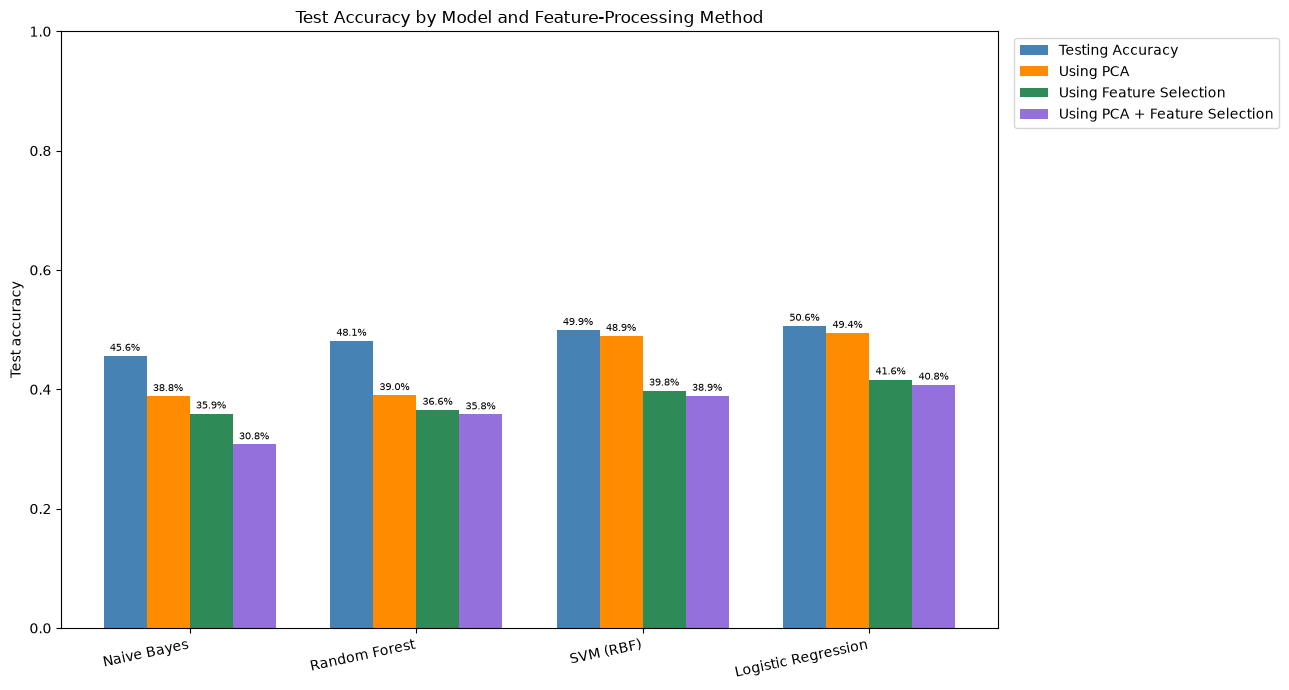

Saved final comparison table: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\results\model_results.csv
Saved baseline model metrics: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\results\model_metrics.csv
Saved chart: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\results\accuracy_comparison.png
Saved baseline reports: C:\Users\prajw\OneDrive\Desktop\Bird-Species-Identification\results\classification_reports.txt


In [9]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
import gc

expected_models = ["Naive Bayes", "Random Forest", "SVM (RBF)", "Logistic Regression"]
missing_models = [name for name in expected_models if name not in model_results]
if missing_models:
    raise RuntimeError(f"Run all model cells before creating final reports; missing: {missing_models}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
transformations = {
    "Using PCA": lambda: [("pca", PCA(n_components=0.95, svd_solver="full"))],
    "Using Feature Selection": lambda: [("feature_selection", SelectKBest(score_func=chi2, k=100))],
    "Using PCA + Feature Selection": lambda: [
        ("feature_selection", SelectKBest(score_func=chi2, k=100)),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
    ],
}
model_factories = {
    "Naive Bayes": lambda: BernoulliNB(),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM (RBF)": lambda: SVC(kernel="rbf", C=1.0, gamma="scale", cache_size=2000),
    "Logistic Regression": lambda: LogisticRegression(solver="lbfgs", max_iter=2000, random_state=42),
}

table_rows = []
for model_name in expected_models:
    baseline = model_results[model_name]
    row = {
        "Method": model_name,
        "Training Accuracy": baseline["training_accuracy"],
        "Testing Accuracy": baseline["accuracy"],
    }
    for transformation_name, make_steps in transformations.items():
        print(f"Training {model_name} — {transformation_name}...")
        pipeline = Pipeline(make_steps() + [("classifier", model_factories[model_name]())])
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_test)
        row[transformation_name] = accuracy_score(y_test, test_predictions)
        print(f"Testing accuracy: {row[transformation_name]:.2%}")
        del pipeline, test_predictions
        gc.collect()
    table_rows.append(row)

accuracy_columns = ["Training Accuracy", "Testing Accuracy", *transformations.keys()]
results_table = pd.DataFrame(table_rows)
display(results_table.style.format({column: "{:.2%}" for column in accuracy_columns}))

results_csv = RESULTS_DIR / "model_results.csv"
results_table.to_csv(results_csv, index=False)
metrics_csv = RESULTS_DIR / "model_metrics.csv"
pd.DataFrame([model_results[name] for name in expected_models]).to_csv(metrics_csv, index=False)

figure, axis = plt.subplots(figsize=(13, 7))
model_names = results_table["Method"].tolist()
positions = np.arange(len(model_names))
bar_width = 0.19
plot_columns = ["Testing Accuracy", *transformations.keys()]
colors = ["steelblue", "darkorange", "seagreen", "mediumpurple"]
for index, (column, color) in enumerate(zip(plot_columns, colors)):
    values = results_table[column].to_numpy()
    bars = axis.bar(positions + (index - 1.5) * bar_width, values, bar_width, label=column, color=color)
    axis.bar_label(bars, labels=[f"{value:.1%}" for value in values], padding=2, fontsize=7)
axis.set_title("Test Accuracy by Model and Feature-Processing Method")
axis.set_ylabel("Test accuracy")
axis.set_xticks(positions, model_names, rotation=12, ha="right")
axis.set_ylim(0, 1.0)
axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
figure.tight_layout()
chart_path = RESULTS_DIR / "accuracy_comparison.png"
figure.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(figure)

reports_path = RESULTS_DIR / "classification_reports.txt"
with reports_path.open("w", encoding="utf-8") as file:
    for model_name in expected_models:
        file.write(f"{'=' * 80}\n{model_name}\n{'=' * 80}\n")
        file.write(classification_reports[model_name])
        file.write("\n\n")

print(f"Saved final comparison table: {results_csv}")
print(f"Saved baseline model metrics: {metrics_csv}")
print(f"Saved chart: {chart_path}")
print(f"Saved baseline reports: {reports_path}")

## Saved files

```text
models/
├── naive_bayes.pkl
├── random_forest.pkl
├── svm_rbf.pkl
└── logistic_regression.pkl

results/
├── model_results.csv          # baseline train/test and transformed test accuracy
├── model_metrics.csv          # baseline F1 scores and runtime metrics
├── accuracy_comparison.png    # test accuracy by model and feature-processing method
└── classification_reports.txt # baseline per-class reports
```

Pickle files should only be loaded from trusted sources. For reproducible loading, use a Python/scikit-learn environment compatible with the one used for training.